# GRU do zero: geração de texto com portas de memória

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flavioluizseixas/aprendizado-de-maquina-para-saude/blob/main/notebooks/RNN/gru_do_zero_d2l.ipynb)

Segundo notebook da série, baseado na seção
[9.1 — Gated Recurrent Units (GRU)](https://pt.d2l.ai/chapter_recurrent-modern/gru.html)
do livro *Dive into Deep Learning* (D2L), de Aston Zhang, Zachary C. Lipton,
Mu Li e Alexander J. Smola.

Implementamos uma **GRU do zero em PyTorch** para prever o próximo caractere
de *The Time Machine*, de H. G. Wells. A recorrência utiliza uma porta de
atualização, uma porta de redefinição (*reset*) e um estado candidato.
Os pesos, as portas, a projeção de saída, o recorte de gradientes e o SGD são
explícitos. Usamos o PyTorch para operações com tensores, entropia cruzada e
diferenciação automática; a retropropagação não é derivada manualmente.

**Como executar:** abra no Jupyter, VS Code ou Colab e execute as células em
ordem. Este notebook contém todas as funções necessárias e não depende da
execução do notebook da RNN nem do pacote `d2l`. O corpus é baixado para
`data/timemachine.txt` apenas se ainda não existir.

O perfil padrão `livro` usa **256 unidades ocultas e 500 épocas**. Para uma
execução curta, selecione `PERFIL = "rapido"`. A comparação com amostragem
aleatória é uma extensão didática; para treinar apenas a variante sequencial,
selecione `TREINAR_ALEATORIO = False`.

Esta adaptação inclui explicações em português, funções auxiliares completas,
inspeção das portas e gráficos de treinamento. O material adaptado é
disponibilizado sob [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/),
conforme a [licença do D2L](https://github.com/d2l-ai/d2l-en/blob/master/LICENSE).


## 1. Dependências e configuração

São necessários Python 3.9 ou superior, PyTorch e Matplotlib. Se os imports
falharem, descomente e execute a instalação abaixo no kernel do notebook.


In [1]:
# Descomente na primeira execução se as bibliotecas ainda não estiverem instaladas.
# %pip install torch matplotlib


In [2]:
import hashlib
import math
import random
import re
import time
from collections import Counter
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F


def fixar_semente(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
PERFIL = "livro"  # "rapido" ou "livro"
PERFIS = {
    "rapido": {"num_hiddens": 128, "num_epochs": 50},
    "livro": {"num_hiddens": 256, "num_epochs": 500},
}
config = PERFIS[PERFIL]
batch_size = 32
num_steps = 35
max_tokens = 10_000
num_hiddens = config["num_hiddens"]
num_epochs = config["num_epochs"]
lr = 1.0
clip_theta = 1.0
TREINAR_ALEATORIO = True

# CPU funciona em qualquer plataforma; CUDA é usada quando disponível.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Matrizes pequenas podem ser mais rápidas com apenas uma thread de CPU.
torch.set_num_threads(1)
fixar_semente(SEED)

print(f"PyTorch {torch.__version__} | dispositivo: {device}")
print(f"Perfil: {PERFIL} | unidades ocultas: {num_hiddens} | épocas: {num_epochs}")


PyTorch 2.8.0 | dispositivo: cpu
Perfil: livro | unidades ocultas: 256 | épocas: 500


## 2. Corpus e vocabulário

O pré-processamento segue a [seção 8.2 do D2L](https://pt.d2l.ai/chapter_recurrent-neural-networks/text-preprocessing.html):
mantemos letras e espaços, convertemos para minúsculas e concatenamos as linhas
sem inserir separadores extras. Assim, algumas palavras no limite entre linhas
ficam unidas, como nos dados do capítulo.

O vocabulário é construído antes de limitar o corpus a 10.000 caracteres.
O índice zero representa `<unk>`, reservado para caracteres desconhecidos.
Os dados estão em inglês; por isso, os textos gerados também estarão.


In [3]:
DATA_URL = "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
DATA_SHA1 = "090b5e7e70c295757f55df93cb0a180b9691891a"
DATA_PATH = Path("data/timemachine.txt")


def ler_time_machine(path=DATA_PATH):
    path = Path(path)
    if not path.exists():
        try:
            with urlopen(DATA_URL, timeout=60) as response:
                data = response.read()
        except (URLError, TimeoutError) as error:
            raise RuntimeError(
                f"Não foi possível baixar o corpus. Baixe {DATA_URL} "
                f"manualmente, salve em {path.resolve()} e execute novamente."
            ) from error
        if hashlib.sha1(data).hexdigest() != DATA_SHA1:
            raise ValueError("O corpus baixado não corresponde ao arquivo do D2L.")
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(data)
    else:
        data = path.read_bytes()
        if hashlib.sha1(data).hexdigest() != DATA_SHA1:
            raise ValueError(f"Checksum incorreto: substitua {path} pelo corpus do D2L.")

    return [
        re.sub(r"[^A-Za-z]+", " ", line).strip().lower()
        for line in data.decode("utf-8").splitlines()
    ]


class Vocab:
    def __init__(self, text):
        self.idx_to_token = ["<unk>"] + [
            token for token, count in Counter(text).most_common()
        ]
        self.token_to_idx = {
            token: index for index, token in enumerate(self.idx_to_token)
        }

    def __len__(self):
        return len(self.idx_to_token)

    def encode(self, text):
        return [self.token_to_idx.get(char, 0) for char in text]

    def decode(self, indices):
        return "".join(self.idx_to_token[int(index)] for index in indices)


lines = ler_time_machine()
text = "".join(lines)
vocab = Vocab(text)
corpus = vocab.encode(text)[:max_tokens]
print(f"Linhas: {len(lines):,} | caracteres usados: {len(corpus):,}")
print(f"Tamanho do vocabulário: {len(vocab)}")
print("Tokens:", vocab.idx_to_token)
print("Trecho:", vocab.decode(corpus[:100]))


Linhas: 3,221 | caracteres usados: 10,000
Tamanho do vocabulário: 28
Tokens: ['<unk>', ' ', 'e', 't', 'a', 'i', 'n', 'o', 's', 'h', 'r', 'd', 'l', 'm', 'u', 'c', 'f', 'w', 'g', 'y', 'p', 'b', 'v', 'k', 'x', 'z', 'j', 'q']
Trecho: the time machine by h g wellsithe time traveller for so it will be convenient to speak of himwas exp


## 3. Minibatches sequenciais e aleatórios

Cada entrada `X` contém índices de caracteres. O alvo `Y` contém os caracteres
seguintes: para `X = "time"`, teríamos `Y = "ime "`.

Na **amostragem sequencial**, uma linha do próximo lote continua a mesma linha
do lote anterior. Na **amostragem aleatória**, embaralhamos subsequências inteiras;
a ordem dos caracteres dentro de cada subsequência é preservada. Os dois
iteradores são recriados a cada época, com um novo deslocamento inicial.
Esse procedimento é apresentado na [seção 8.3 do D2L](https://pt.d2l.ai/chapter_recurrent-neural-networks/language-models-and-dataset.html).


In [4]:
def seq_data_iter_sequential(corpus, batch_size, num_steps, rng):
    offset = rng.randint(0, num_steps)
    usable = ((len(corpus) - offset - 1) // batch_size) * batch_size
    if usable < batch_size * num_steps:
        raise ValueError("Corpus insuficiente: reduza batch_size ou num_steps.")
    inputs = torch.tensor(corpus[offset:offset + usable], dtype=torch.long)
    targets = torch.tensor(corpus[offset + 1:offset + usable + 1], dtype=torch.long)
    inputs = inputs.reshape(batch_size, -1)
    targets = targets.reshape(batch_size, -1)
    for start in range(0, inputs.shape[1] - num_steps + 1, num_steps):
        yield inputs[:, start:start + num_steps], targets[:, start:start + num_steps]


def seq_data_iter_random(corpus, batch_size, num_steps, rng):
    offset = rng.randrange(num_steps)
    subsequences = (len(corpus) - offset - 1) // num_steps
    starts = [offset + i * num_steps for i in range(subsequences)]
    if len(starts) < batch_size:
        raise ValueError("Corpus insuficiente: reduza batch_size ou num_steps.")
    rng.shuffle(starts)
    for first in range(0, len(starts) - batch_size + 1, batch_size):
        batch_starts = starts[first:first + batch_size]
        inputs = [corpus[start:start + num_steps] for start in batch_starts]
        targets = [corpus[start + 1:start + num_steps + 1] for start in batch_starts]
        yield torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)


class SeqDataLoader:
    def __init__(self, corpus, batch_size, num_steps, use_random_iter=False, seed=42):
        if batch_size < 1 or num_steps < 1:
            raise ValueError("batch_size e num_steps devem ser positivos.")
        self.corpus = corpus
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.use_random_iter = use_random_iter
        self.rng = random.Random(seed)

    def __iter__(self):
        iterator = seq_data_iter_random if self.use_random_iter else seq_data_iter_sequential
        return iterator(self.corpus, self.batch_size, self.num_steps, self.rng)


demo_loader = SeqDataLoader(corpus, batch_size, num_steps, seed=SEED)
X, Y = next(iter(demo_loader))
assert torch.equal(X[:, 1:], Y[:, :-1])
print("Dimensões de X e Y:", tuple(X.shape), tuple(Y.shape))
print("X[0]:", repr(vocab.decode(X[0])))
print("Y[0]:", repr(vocab.decode(Y[0])))


Dimensões de X e Y: (32, 35) (32, 35)
X[0]: 'e machine by h g wellsithe time tra'
Y[0]: ' machine by h g wellsithe time trav'


## 4. Codificação one-hot

Se o vocabulário tem $V$ tokens, cada índice vira um vetor de tamanho $V$ com
um único valor 1. Transpomos o lote para percorrer primeiro o tempo:

| Tensor | Dimensões |
|---|---|
| Índices `X` | `(batch_size, num_steps)` |
| Entrada one-hot | `(num_steps, batch_size, vocab_size)` |
| Estado oculto | `(batch_size, num_hiddens)` |
| Logits de todos os passos | `(num_steps * batch_size, vocab_size)` |


In [5]:
print("Exemplo com três tokens:")
print(F.one_hot(torch.tensor([0, 2]), num_classes=3))
X_one_hot = F.one_hot(X.T, num_classes=len(vocab)).to(torch.float32)
assert X_one_hot.shape == (num_steps, batch_size, len(vocab))
assert torch.all(X_one_hot.sum(dim=-1) == 1)
print("Dimensões após one-hot:", tuple(X_one_hot.shape))


Exemplo com três tokens:
tensor([[1, 0, 0],
        [0, 0, 1]])
Dimensões após one-hot: (35, 32, 28)


## 5. Portas, estado candidato e recorrência GRU

Cada passo recebe a entrada $X_t$ e o estado anterior $H_{t-1}$. As portas
decidem quanto preservar desse estado e quanto dele usar para construir uma
nova proposta de memória:

$$Z_t = \sigma(X_t W_{xz} + H_{t-1} W_{hz} + b_z)$$
$$R_t = \sigma(X_t W_{xr} + H_{t-1} W_{hr} + b_r)$$
$$\widetilde H_t = \tanh\left(X_t W_{xh} + (R_t \odot H_{t-1}) W_{hh} + b_h\right)$$
$$H_t = Z_t \odot H_{t-1} + (1-Z_t) \odot \widetilde H_t$$
$$O_t = H_t W_{hq} + b_q$$

$\sigma$ é a função sigmoide e $\odot$ representa multiplicação elemento a
elemento. As portas têm a mesma forma do estado: `(batch_size, num_hiddens)`.

| Comportamento da porta | Consequência |
|---|---|
| $Z_t$ próximo de 1 | Preserva o estado anterior. |
| $Z_t$ próximo de 0 | Aproxima o estado do candidato. |
| $R_t$ próximo de 0 | Reduz a contribuição direta do estado anterior para o candidato. |
| $R_t$ próximo de 1 | Permite que todo o estado anterior entre no cálculo do candidato. |

Mesmo com $R_t$ próximo de zero, o estado anterior ainda pode ser preservado
por $Z_t$. A porta de redefinição não zera automaticamente a memória inteira.

Temos **11 tensores treináveis**: três para cada porta, três para o candidato
e dois para a saída. As matrizes começam com ruído normal de desvio padrão
0,01; os vieses e o estado inicial começam em zero. `O_t` contém logits.

**Convenção adotada:** seguimos a implementação do zero do D2L, na qual o
reset é aplicado **antes** da multiplicação recorrente: `(R * H) @ W_hh`.
A implementação `torch.nn.GRU` aplica essa porta após a transformação
recorrente, como explica a [documentação do PyTorch](https://docs.pytorch.org/docs/2.8/generated/torch.nn.GRU.html).
Assim, copiar os pesos entre as duas variantes não garante saídas idênticas.


In [6]:
def get_params(vocab_size, num_hiddens, device):
    shapes = {
        # Porta de atualização: controla a preservação do estado anterior.
        "W_xz": (vocab_size, num_hiddens),
        "W_hz": (num_hiddens, num_hiddens),
        "b_z": (num_hiddens,),
        # Porta de redefinição: filtra o estado que entra no candidato.
        "W_xr": (vocab_size, num_hiddens),
        "W_hr": (num_hiddens, num_hiddens),
        "b_r": (num_hiddens,),
        # Estado candidato.
        "W_xh": (vocab_size, num_hiddens),
        "W_hh": (num_hiddens, num_hiddens),
        "b_h": (num_hiddens,),
        # Projeção do estado para os logits do próximo caractere.
        "W_hq": (num_hiddens, vocab_size),
        "b_q": (vocab_size,),
    }
    params = {}
    for name, shape in shapes.items():
        value = (0.01 * torch.randn(shape, device=device)
                 if name.startswith("W") else torch.zeros(shape, device=device))
        params[name] = value.requires_grad_()
    return params


def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros(batch_size, num_hiddens, device=device),)


def gru_step(X, H, params):
    """Executa um passo e retorna o estado novo e as grandezas internas."""
    Z = torch.sigmoid(X @ params["W_xz"] + H @ params["W_hz"] + params["b_z"])
    R = torch.sigmoid(X @ params["W_xr"] + H @ params["W_hr"] + params["b_r"])
    H_tilde = torch.tanh(
        X @ params["W_xh"] + (R * H) @ params["W_hh"] + params["b_h"]
    )
    H_new = Z * H + (1 - Z) * H_tilde
    return H_new, (Z, R, H_tilde)


def gru(inputs, state, params):
    hidden, = state
    logits_by_step = []
    for x_t in inputs:
        hidden, _ = gru_step(x_t, hidden, params)
        logits_by_step.append(hidden @ params["W_hq"] + params["b_q"])
    # Ordem: tempo, lote, vocabulário. Os alvos seguirão a mesma ordem.
    logits = torch.stack(logits_by_step).reshape(-1, params["b_q"].numel())
    return logits, (hidden,)


class GRUModelScratch:
    def __init__(self, vocab_size, num_hiddens, device):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.device = torch.device(device)
        self.params = get_params(vocab_size, num_hiddens, self.device)

    def begin_state(self, batch_size):
        return init_gru_state(batch_size, self.num_hiddens, self.device)

    def __call__(self, X, state):
        one_hot = F.one_hot(X.T, num_classes=self.vocab_size).to(torch.float32)
        return gru(one_hot, state, self.params)


fixar_semente(SEED)
net = GRUModelScratch(len(vocab), num_hiddens, device)
with torch.no_grad():
    logits, state = net(X.to(device), net.begin_state(X.shape[0]))
assert logits.shape == (num_steps * batch_size, len(vocab))
assert state[0].shape == (batch_size, num_hiddens)
assert len(net.params) == 11
print("Logits:", tuple(logits.shape), "| estado:", tuple(state[0].shape))
print("Tensores treináveis:", len(net.params))
print("Parâmetros treináveis:", sum(p.numel() for p in net.params.values()))


Logits: (1120, 28) | estado: (32, 256)
Tensores treináveis: 11
Parâmetros treináveis: 226076


### Observando as portas antes do treinamento

Com pesos pequenos, vieses nulos e estado inicial zero, as sigmoides
produzem valores próximos de 0,5. Os valores das portas serão ajustados
durante o treinamento; eles não são hiperparâmetros fixos.
A célula abaixo inspeciona o primeiro passo do lote.


In [7]:
with torch.no_grad():
    X_first = F.one_hot(X[:, 0].to(device), len(vocab)).float()
    H_initial, = net.begin_state(X.shape[0])
    H_first, (Z, R, H_tilde) = gru_step(X_first, H_initial, net.params)
    for name, values in [("Atualização Z", Z), ("Redefinição R", R)]:
        print(
            f"{name}: mínimo={values.min().item():.4f}, "
            f"média={values.mean().item():.4f}, máximo={values.max().item():.4f}"
        )
    assert torch.all((Z >= 0) & (Z <= 1))
    assert torch.all((R >= 0) & (R <= 1))
    print("Estado candidato:", tuple(H_tilde.shape))
    print("Estado atualizado:", tuple(H_first.shape))


Atualização Z: mínimo=0.4904, média=0.5000, máximo=0.5086
Redefinição R: mínimo=0.4905, média=0.5000, máximo=0.5091
Estado candidato: (32, 256)
Estado atualizado: (32, 256)


## 6. Geração a partir de um prefixo

Primeiro processamos todos os caracteres do prefixo para atualizar a memória.
Depois escolhemos o token com maior logit (`argmax`) e o realimentamos na rede.
`torch.no_grad()` evita construir um grafo de gradientes durante a geração.
Antes do treinamento, as previsões ainda não representam padrões do texto.


In [8]:
@torch.no_grad()
def predict(prefix, num_preds, net, vocab):
    prefix = prefix.lower()
    if not prefix:
        raise ValueError("Forneça um prefixo não vazio.")
    if num_preds < 0:
        raise ValueError("num_preds deve ser maior ou igual a zero.")
    unknown = sorted(set(prefix) - set(vocab.token_to_idx))
    if unknown:
        raise ValueError(f"Caracteres fora do vocabulário: {unknown!r}")

    indices = vocab.encode(prefix)
    state = net.begin_state(batch_size=1)
    for index in indices:  # Aquecimento com o prefixo completo.
        step = torch.tensor([[index]], dtype=torch.long, device=net.device)
        logits, state = net(step, state)
    for _ in range(num_preds):
        next_index = int(logits.argmax(dim=-1).item())
        indices.append(next_index)
        step = torch.tensor([[next_index]], dtype=torch.long, device=net.device)
        logits, state = net(step, state)
    return vocab.decode(indices)


print("Antes de treinar:", predict("time traveller ", 50, net, vocab))


Antes de treinar: time traveller zvssypmuipu<unk>ipu<unk>ipu<unk>ipu<unk>ipu<unk>ipu<unk>ipu<unk>ipu<unk>ipu<unk>ipu<unk>ip


## 7. Recorte de gradientes e SGD manual

Calculamos a norma global $\|g\|_2$ considerando todos os parâmetros.
Se ela ultrapassa $\theta$, multiplicamos todos os gradientes por
$\theta / \|g\|_2$, preservando a direção. Isso limita a magnitude de uma
atualização, mas não resolve o desaparecimento de gradientes.

O SGD aplica $w \leftarrow w - \eta g$. Como a perda já é uma **média por token**,
não dividimos o gradiente novamente pelo tamanho do lote. A atualização ocorre
fora do grafo, e os gradientes são limpos antes da próxima retropropagação.


In [9]:
@torch.no_grad()
def grad_clipping(params, theta):
    if theta <= 0:
        raise ValueError("theta deve ser positivo.")
    grads = [p.grad for p in params.values() if p.grad is not None]
    if not grads:
        return 0.0
    norm = torch.sqrt(torch.stack([g.square().sum() for g in grads]).sum())
    if not torch.isfinite(norm).item():
        raise FloatingPointError("Gradientes não finitos; verifique a taxa de aprendizado.")
    scale = (theta / norm.clamp_min(1e-12)).clamp(max=1.0)
    for grad in grads:
        grad.mul_(scale)
    return norm.item()


@torch.no_grad()
def sgd(params, lr):
    for param in params.values():
        if param.grad is not None:
            param.add_(param.grad, alpha=-lr)


# Exemplo independente: um vetor de norma 5 deve ficar com norma 1.
dummy = torch.zeros(2, device=device, requires_grad=True)
dummy.grad = torch.tensor([3.0, 4.0], device=device)
norm_before = grad_clipping({"dummy": dummy}, theta=1.0)
norm_after = dummy.grad.norm().item()
assert math.isclose(norm_before, 5.0, rel_tol=1e-5)
assert math.isclose(norm_after, 1.0, rel_tol=1e-5)
print(f"Norma antes: {norm_before:.2f} | depois: {norm_after:.2f}")


Norma antes: 5.00 | depois: 1.00


## 8. Treinamento e perplexidade

Na amostragem sequencial, reutilizamos o **valor** do estado entre lotes e
usamos `detach()` para interromper o grafo anterior. Assim, a retropropagação
fica limitada aos `num_steps` do lote atual (BPTT truncada). Na amostragem
aleatória, reinicializamos o estado em cada lote. Toda época começa com estado zero.

Os logits foram organizados primeiro por tempo; por isso os alvos são
`Y.T.reshape(-1)`. A perda é a entropia cruzada média e a perplexidade é
$\exp(\text{perda média})$. Agregamos a perda ponderando pelo número de tokens.
O gráfico mede **perplexidade de treinamento**, não generalização em texto novo.


In [10]:
def sincronizar(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def train_epoch(net, loader, lr, theta):
    state = None
    loss_sum = 0.0
    token_count = 0
    max_grad_norm = 0.0
    sincronizar(net.device)
    start = time.perf_counter()

    for X, Y in loader:
        X = X.to(net.device)
        targets = Y.T.reshape(-1).to(net.device)
        if state is None or loader.use_random_iter:
            state = net.begin_state(X.shape[0])
        else:
            state = tuple(value.detach() for value in state)

        for param in net.params.values():
            param.grad = None
        logits, state = net(X, state)
        loss = F.cross_entropy(logits, targets)
        if not torch.isfinite(loss).item():
            raise FloatingPointError("Perda não finita; experimente reduzir lr.")
        loss.backward()
        max_grad_norm = max(max_grad_norm, grad_clipping(net.params, theta))
        sgd(net.params, lr)

        loss_sum += loss.item() * targets.numel()
        token_count += targets.numel()

    if token_count == 0:
        raise ValueError("Nenhum lote completo foi produzido.")
    sincronizar(net.device)
    elapsed = time.perf_counter() - start
    mean_loss = loss_sum / token_count
    return {
        "loss": mean_loss,
        "perplexity": math.exp(mean_loss),
        "tokens_per_second": token_count / elapsed,
        "max_grad_norm": max_grad_norm,
    }


def train(net, loader, vocab, num_epochs, lr, theta=1.0):
    history = []
    for epoch in range(1, num_epochs + 1):
        metrics = train_epoch(net, loader, lr, theta)
        metrics["epoch"] = epoch
        history.append(metrics)
        if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
            print(
                f"Época {epoch:3d}/{num_epochs} | "
                f"perplexidade: {metrics['perplexity']:.3f} | "
                f"{metrics['tokens_per_second']:,.0f} tokens/s"
            )
            print("  ", predict("time traveller ", 50, net, vocab))
    return history


### Treinamento com amostragem sequencial

O perfil `livro` usa 256 unidades ocultas e 500 épocas, mantendo lote 32,
sequências de 35 passos, 10.000 tokens e taxa de aprendizado 1, como na
implementação do zero do capítulo. O perfil `rapido` usa 128 unidades e
50 épocas e serve para observar a execução; seu texto pode ficar repetitivo.

O treinamento reutiliza o estado entre lotes sequenciais, mas interrompe o
grafo com `detach()`. O tempo de execução e as saídas dependem do hardware
e da versão do PyTorch.


In [11]:
# Recriar modelo e iterador torna esta célula independente de treinos anteriores.
fixar_semente(SEED)
net_seq = GRUModelScratch(len(vocab), num_hiddens, device)
loader_seq = SeqDataLoader(corpus, batch_size, num_steps, seed=SEED)
history_seq = train(net_seq, loader_seq, vocab, num_epochs, lr, clip_theta)


Época   1/500 | perplexidade: 24.928 | 33,532 tokens/s
   time traveller                                                   


Época  10/500 | perplexidade: 17.194 | 34,358 tokens/s
   time traveller                                                   


Época  20/500 | perplexidade: 15.401 | 50,991 tokens/s
   time traveller ate te ate te ate te ate te ate te ate te ate te a


Época  30/500 | perplexidade: 12.773 | 43,546 tokens/s
   time traveller ate the ate the ate the ate the ate the ate the at


Época  40/500 | perplexidade: 11.597 | 64,287 tokens/s
   time traveller an the the the the the the the the the the the the


...

Época 460/500 | perplexidade: 1.067 | 69,720 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


Época 470/500 | perplexidade: 1.065 | 69,415 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


Época 480/500 | perplexidade: 1.066 | 69,276 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


Época 490/500 | perplexidade: 1.066 | 69,257 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


Época 500/500 | perplexidade: 1.049 | 69,251 tokens/s
   time traveller for so it will be convenient to speak of himwas ex


### Comparação adicional: amostragem aleatória

Como no primeiro notebook, treinamos também um modelo novo com subsequências
embaralhadas. Esta comparação amplia o experimento sequencial do capítulo.
Usamos a mesma semente para a inicialização dos pesos e zeramos o estado em
cada lote. Defina `TREINAR_ALEATORIO = False` para desativar este segundo treino.


In [12]:
history_random = []
net_random = None
if TREINAR_ALEATORIO:
    fixar_semente(SEED)
    net_random = GRUModelScratch(len(vocab), num_hiddens, device)
    loader_random = SeqDataLoader(
        corpus, batch_size, num_steps, use_random_iter=True, seed=SEED
    )
    history_random = train(net_random, loader_random, vocab, num_epochs, lr, clip_theta)
else:
    print("Treinamento aleatório desativado na configuração.")


Época   1/500 | perplexidade: 24.939 | 68,441 tokens/s
   time traveller                                                   


Época  10/500 | perplexidade: 17.231 | 68,386 tokens/s
   time traveller                                                   


Época  20/500 | perplexidade: 15.339 | 68,871 tokens/s
   time traveller at at at at at at at at at at at at at at at at at


Época  30/500 | perplexidade: 12.743 | 69,018 tokens/s
   time traveller an the the the the the the the the the the the the


Época  40/500 | perplexidade: 11.368 | 68,765 tokens/s
   time traveller an the the the the the the the the the the the the


...

Época 460/500 | perplexidade: 1.631 | 69,230 tokens/s
   time traveller smiled are you sure we can move freely inspace rig


Época 470/500 | perplexidade: 1.553 | 69,113 tokens/s
   time traveller smiled all that idea you have allheard what they h


Época 480/500 | perplexidade: 1.525 | 68,267 tokens/s
   time traveller smiled round at us then still smiling faintlyand w


Época 490/500 | perplexidade: 1.520 | 69,627 tokens/s
   time traveller smiled round at us then still smiling faintlyand w


Época 500/500 | perplexidade: 1.493 | 69,090 tokens/s
   time traveller smiled are you sure we can move freely inspace rig


## 9. Curvas e texto gerado

Quanto menor a perplexidade, maior a probabilidade atribuída aos alvos vistos
no treino. Uma distribuição uniforme teria perplexidade igual ao tamanho do
vocabulário. Uma única execução não permite concluir qual amostragem é superior.


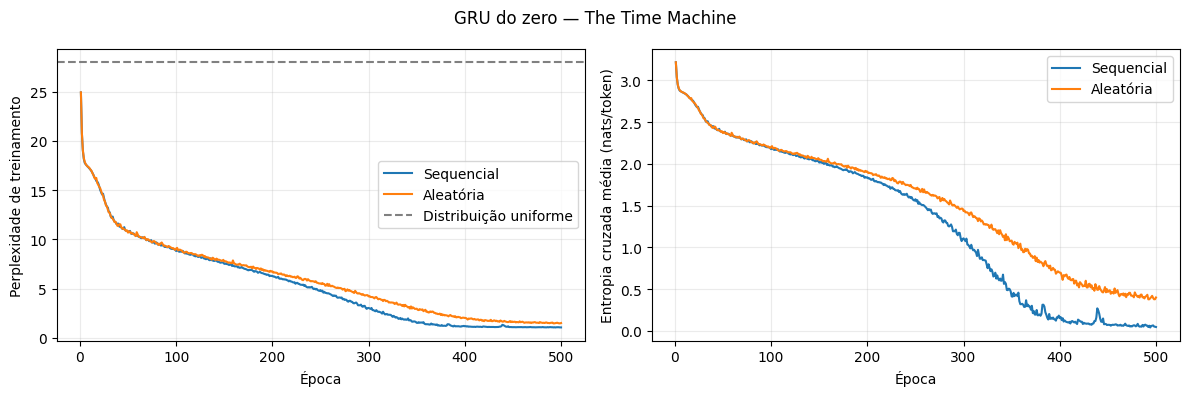

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, history in [("Sequencial", history_seq), ("Aleatória", history_random)]:
    if not history:
        continue
    epochs = [item["epoch"] for item in history]
    axes[0].plot(epochs, [item["perplexity"] for item in history], label=label)
    axes[1].plot(epochs, [item["loss"] for item in history], label=label)

axes[0].axhline(len(vocab), linestyle="--", color="gray", label="Distribuição uniforme")
axes[0].set_ylabel("Perplexidade de treinamento")
axes[1].set_ylabel("Entropia cruzada média (nats/token)")
for ax in axes:
    ax.set_xlabel("Época")
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle("GRU do zero — The Time Machine")
fig.tight_layout()
plt.show()


In [14]:
for label, model, history in [
    ("Sequencial", net_seq, history_seq),
    ("Aleatória", net_random, history_random),
]:
    if model is None:
        continue
    print(f"\n{label} | perplexidade final de treino: {history[-1]['perplexity']:.3f}")
    for prefix in ("time traveller ", "traveller ", "the time machine "):
        print(predict(prefix, 50, model, vocab))



Sequencial | perplexidade final de treino: 1.049
time traveller for so it will be convenient to speak of himwas ex
traveller with a slight accession ofcheerfulness really this
the time machine by h g wellsithe time traveller for so it will be 

Aleatória | perplexidade final de treino: 1.493
time traveller smiled are you sure we can move freely inspace rig
traveller comels of my great discovery but you are wrong tha
the time machine by hs gensiveden the mechanismthen he drew up a ch


## 10. Experimentos sugeridos

1. Compare os perfis `livro` e `rapido` e observe a qualidade do texto gerado.
2. Compare esta GRU com a RNN do primeiro notebook usando o mesmo número de
   unidades ocultas, as mesmas épocas, o mesmo corpus e o mesmo dispositivo.
   Os perfis `livro` dos dois capítulos usam tamanhos ocultos diferentes.
3. Inspecione `Z` e `R` com `gru_step` após o treinamento, passando os pesos
   de `net_seq`, e compare os valores com os observados na inicialização.
4. Experimente fixar `Z = 0` ou `R = 1` dentro de `gru_step`, treine um modelo
   novo e observe quais mecanismos de memória foram removidos.
5. Para avaliar generalização, reserve um trecho contínuo para validação antes
   de construir os iteradores e calcule a perda sem atualizar os pesos.

A perplexidade exibida é de **treinamento**. Valores próximos de 1 podem
refletir memorização dos 10.000 caracteres. As portas ajudam a controlar o
fluxo de informação, mas não garantem aprendizado de dependências longas.
A semente favorece a repetição no mesmo ambiente; resultados entre versões
ou dispositivos podem variar.
